In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use("ggplot")

sales = pd.read_csv("../data/Sales_data.csv")
products = pd.read_csv("../data/products_information.csv")
stores = pd.read_csv("../data/stores_information.csv")
payments = pd.read_csv("../data/payments_information.csv")
promotions = pd.read_csv("../data/promotions_information.csv")
customers =pd.read_csv("../data/Customers_Information.csv")


print("Sales:", sales.shape)
print("Products:", products.shape)
print("Stores:", stores.shape)
print("Payments:", payments.shape)
print("Promotions:", promotions.shape)
pd.set_option("display.float_format", "{:,.2f}".format)



Sales: (650000, 14)
Products: (2200, 5)
Stores: (180, 4)
Payments: (5, 2)
Promotions: (120, 3)


## Dataset Overview

In [10]:


print("===== SALES =====")
sales.info()

print("\n===== PRODUCTS =====")
products.info()

print("\n===== STORES =====")
stores.info()

print("\n===== PAYMENTS =====")
payments.info()

print("\n===== PROMOTIONS =====")
promotions.info()

===== SALES =====
<class 'pandas.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   OrderID          650000 non-null  str    
 1   OrderDateTime    650000 non-null  str    
 2   CustomerID       650000 non-null  str    
 3   ProductID        650000 non-null  str    
 4   StoreID          650000 non-null  str    
 5   PaymentID        650000 non-null  str    
 6   PromotionID      644556 non-null  str    
 7   Quantity         650000 non-null  int64  
 8   UnitPrice        650000 non-null  float64
 9   GrossAmount      650000 non-null  float64
 10  DiscountAmount   650000 non-null  float64
 11  NetAmount        650000 non-null  float64
 12  DeliveryMinutes  650000 non-null  int64  
 13  OrderStatus      650000 non-null  str    
dtypes: float64(4), int64(2), str(8)
memory usage: 69.4 MB

===== PRODUCTS =====
<class 'pandas.DataFrame'>
RangeIndex: 2200 entri

## Data Quality Assessment

In [11]:

datasets = {
    "Sales": sales,
    "Products": products,
    "Stores": stores,
    "Payments": payments,
    "Promotions": promotions
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Sales
OrderID               0
OrderDateTime         0
CustomerID            0
ProductID             0
StoreID               0
PaymentID             0
PromotionID        5444
Quantity              0
UnitPrice             0
GrossAmount           0
DiscountAmount        0
NetAmount             0
DeliveryMinutes       0
OrderStatus           0
dtype: int64

Products
ProductID      0
ProductName    0
Category       0
Brand          0
MRP            0
dtype: int64

Stores
StoreID        0
StoreName      0
City           0
OpeningYear    0
dtype: int64

Payments
PaymentID        0
PaymentMethod    0
dtype: int64

Promotions
PromotionID        0
PromotionType      0
DiscountPercent    0
dtype: int64


In [12]:

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Sales: 0 duplicate rows
Products: 0 duplicate rows
Stores: 0 duplicate rows
Payments: 0 duplicate rows
Promotions: 0 duplicate rows


In [13]:
print("Unique Customers :", sales["CustomerID"].nunique())

print("Unique Products  :", sales["ProductID"].nunique())

print("Unique Stores    :", sales["StoreID"].nunique())

print("Unique Payments  :", sales["PaymentID"].nunique())

print("Unique Promotions:", sales["PromotionID"].nunique())

Unique Customers : 25000
Unique Products  : 2200
Unique Stores    : 180
Unique Payments  : 5
Unique Promotions: 120


### Observation

- PromotionID contains 5,444 null values (0.84% of all orders).

- These represent orders where no promotional offer was applied.

- Hence, the null values are valid business data and are retained.

In [20]:


sales["OrderDateTime"] = pd.to_datetime(sales["OrderDateTime"])


sales["Year"] = sales["OrderDateTime"].dt.year
sales["Month"] = sales["OrderDateTime"].dt.month
sales["Month_Name"] = sales["OrderDateTime"].dt.month_name()
sales["Quarter"] = sales["OrderDateTime"].dt.quarter
sales["Day"] = sales["OrderDateTime"].dt.day
sales["Hour"] = sales["OrderDateTime"].dt.hour

sales.head()

,OrderID,OrderDateTime,CustomerID,ProductID,StoreID,PaymentID,PromotionID,Quantity,UnitPrice,GrossAmount,...,NetAmount,DeliveryMinutes,OrderStatus,Year,Month,MonthName,Quarter,Day,Hour,Month_Name
0,ORDVNR1ANUN3T,2023-07-21 04:37:00,CUSTAKL9HQ0PU7,PROD9ZVRX3UEZ9,STR6TQ4D5J9IH,PAYCPPZXPL027,PROMOZ0RCPAQKPL,2,897.58,1795.16,...,1505.47,25,Delivered,2023,7,July,3,21,4,July
1,ORD86D1R7PLT2,2024-11-08 04:39:00,CUSTFZILYFV63R,PRODLOPWD7N1G1,STR4SN7WAP9LT,PAYCPPZXPL027,PROMOC3IC66BSH3,1,900.18,900.18,...,837.56,8,Cancelled,2024,11,November,4,8,4,November
2,ORDSOO3N4NJV3,2024-06-17 10:24:00,CUST2X37B97UAC,PRODQ0YT2A4OY8,STRPOQGP6SIYN,PAYCPPZXPL027,PROMO1OVD434WVE,5,376.60,1883.00,...,1640.86,25,Delivered,2024,6,June,2,17,10,June
3,ORDDMGIJAI3D8,2024-09-16 12:04:00,CUSTMEANOR0EST,PROD3KGD7FD5IZ,STRCEBHPT31ZW,PAYCPPZXPL027,PROMO7Y92599PZP,4,451.23,1804.92,...,1732.67,18,Returned,2024,9,September,3,16,12,September
4,ORDFHZ7M9M684,2023-09-15 23:27:00,CUSTHG3ZOZTJ8N,PRODSXEQSX3O74,STRAD5LFMZJNX,PAYCPPZXPL027,PROMOYIAH1QHT88,5,1414.18,7070.90,...,5627.14,10,Delivered,2023,9,September,3,15,23,September


In [22]:
sales["Year"] = sales["OrderDateTime"].dt.year
sales["Month"] = sales["OrderDateTime"].dt.month
sales["Month_Name"] = sales["OrderDateTime"].dt.month_name()
sales["Quarter"] = sales["OrderDateTime"].dt.quarter
sales["Day"] = sales["OrderDateTime"].dt.day
sales["Day_Name"] = sales["OrderDateTime"].dt.day_name()
sales["Hour"] = sales["OrderDateTime"].dt.hour

In [23]:
sales[["OrderDateTime","Year","Month_Name"]].head()

,OrderDateTime,Year,Month_Name
0,2023-07-21 04:37:00,2023,July
1,2024-11-08 04:39:00,2024,November
2,2024-06-17 10:24:00,2024,June
3,2024-09-16 12:04:00,2024,September
4,2023-09-15 23:27:00,2023,September


In [29]:
monthly_revenue = (
    sales.groupby(["Year", "Month_Name"])["NetAmount"]
    .sum()
    .reset_index()
)

monthly_revenue.head()



,Year,Month_Name,NetAmount
0,2023,April,46615453.57
1,2023,August,47274392.46
2,2023,December,47227155.45
3,2023,February,42649640.05
4,2023,January,48277313.55


In [28]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue["Month_Name"] = pd.Categorical(
    monthly_revenue["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_values(
    ["Year","Month_Name"]
)

In [32]:
monthly_revenue = (
    sales
    .set_index("OrderDateTime")
    .resample("ME")["NetAmount"]
    .sum()
    .reset_index()
)

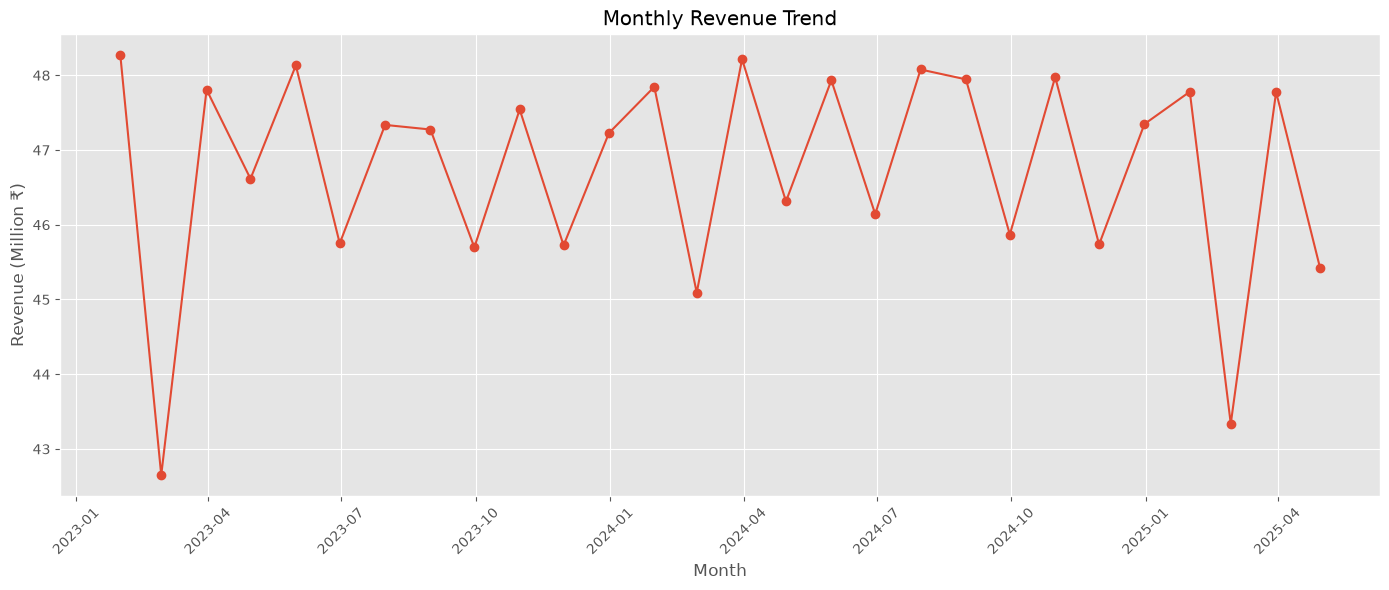

In [50]:
monthly_revenue["Revenue_M"] = monthly_revenue["NetAmount"] / 1_000_000
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["OrderDateTime"],
    monthly_revenue["Revenue_M"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Million ₹)")


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Monthly Revenue Trend

### Objective
Analyze how monthly revenue changed over time to identify growth patterns, seasonality, or unusual fluctuations.

### Key Observations
- Monthly revenue remains relatively stable throughout the observed period.
- Revenue fluctuates within a narrow range, indicating consistent order volume.
- No strong seasonal spikes or prolonged declines are visible in the dataset.

### Business Insight
The stable revenue trend suggests predictable customer demand. This provides a good foundation for introducing AI-powered personalized recommendations and smart promotional targeting to drive incremental revenue growth rather than relying on seasonal demand.

In [34]:
sales_products = sales.merge(
    products,
    on="ProductID",
    how="left"
)

sales_products.head()

,OrderID,OrderDateTime,CustomerID,ProductID,StoreID,PaymentID,PromotionID,Quantity,UnitPrice,GrossAmount,...,MonthName,Quarter,Day,Hour,Month_Name,Day_Name,ProductName,Category,Brand,MRP
0,ORDVNR1ANUN3T,2023-07-21 04:37:00,CUSTAKL9HQ0PU7,PROD9ZVRX3UEZ9,STR6TQ4D5J9IH,PAYCPPZXPL027,PROMOZ0RCPAQKPL,2,897.58,1795.16,...,July,3,21,4,July,Friday,Minus Item,Snacks,Local,897.58
1,ORD86D1R7PLT2,2024-11-08 04:39:00,CUSTFZILYFV63R,PRODLOPWD7N1G1,STR4SN7WAP9LT,PAYCPPZXPL027,PROMOC3IC66BSH3,1,900.18,900.18,...,November,4,8,4,November,Friday,Incidunt Item,Fruits,Nestle,900.18
2,ORDSOO3N4NJV3,2024-06-17 10:24:00,CUST2X37B97UAC,PRODQ0YT2A4OY8,STRPOQGP6SIYN,PAYCPPZXPL027,PROMO1OVD434WVE,5,376.60,1883.00,...,June,2,17,10,June,Monday,Ratione Item,Personal Care,Pepsi,376.60
3,ORDDMGIJAI3D8,2024-09-16 12:04:00,CUSTMEANOR0EST,PROD3KGD7FD5IZ,STRCEBHPT31ZW,PAYCPPZXPL027,PROMO7Y92599PZP,4,451.23,1804.92,...,September,3,16,12,September,Monday,Iure Item,Dairy,Haldirams,451.23
4,ORDFHZ7M9M684,2023-09-15 23:27:00,CUSTHG3ZOZTJ8N,PRODSXEQSX3O74,STRAD5LFMZJNX,PAYCPPZXPL027,PROMOYIAH1QHT88,5,1414.18,7070.90,...,September,3,15,23,September,Friday,Repellat Item,Personal Care,Pepsi,1414.18


In [37]:
category_revenue = (
    sales_products
    .groupby("Category")["NetAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_revenue

Category
Beverages       172,554,574.34
Fruits          171,879,174.55
Personal Care   170,256,444.35
Snacks          167,247,649.51
Vegetables      164,998,033.74
Cleaning        160,646,129.61
Frozen          154,001,517.93
Dairy           147,260,544.03
Name: NetAmount, dtype: float64

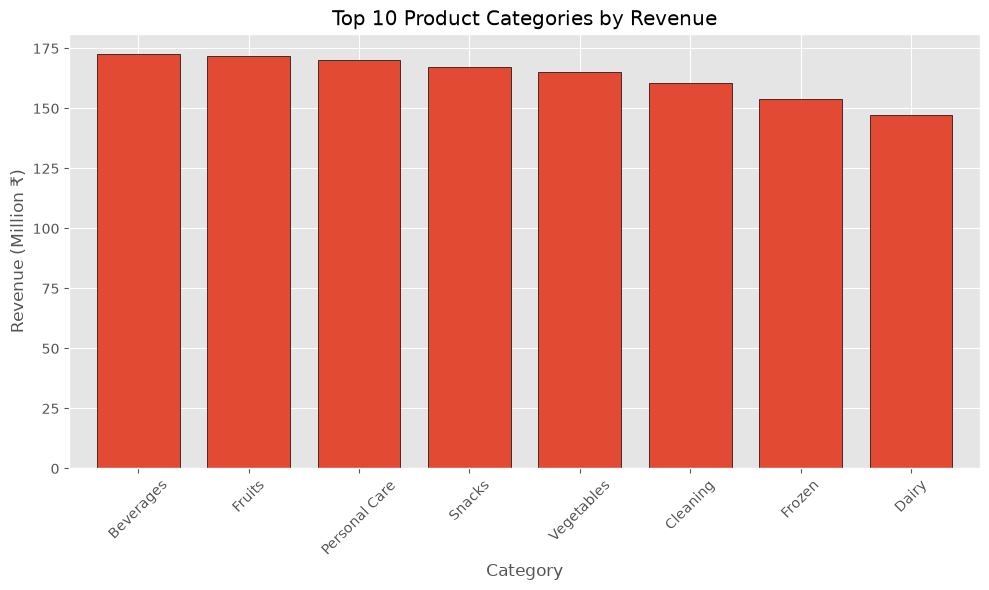

In [51]:
plt.figure(figsize=(10,6))
category_revenue_m = category_revenue / 1_000_000

category_revenue_m.plot(
    kind="bar",
    edgecolor="black",
    width=0.75
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (Million ₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Top Product Categories by Revenue

### Objective
Identify which product categories contribute the highest revenue and understand customer purchasing preferences.

### Key Observations
- A few categories contribute significantly more revenue than others.
- Categories such as Beverages, Fruits, Personal Care and Snacks consistently generate the highest sales.
- High-performing categories represent the largest revenue opportunities for business growth.

### Business Insight
Revenue concentration in a small number of categories highlights where personalized recommendations, dynamic promotions and inventory optimization can generate the highest business impact. These categories should receive priority in AI-powered recommendation strategies.

In [58]:
sales_city = sales.merge(
    stores[["StoreID", "City"]],
    on="StoreID",
    how="left"
)
city_revenue = (
    sales_city.groupby("City")["NetAmount"]
    .sum()
    .sort_values(ascending=False)
)
city_revenue_m = (city_revenue / 1_000_000).round(2)

city_revenue_m

City
Chennai     203.46
Delhi       182.12
Mumbai      173.80
Pune        167.09
Bangalore   138.45
Gurgaon     137.17
Kolkata     102.99
Noida       101.96
Hyderabad   101.80
Name: NetAmount, dtype: float64

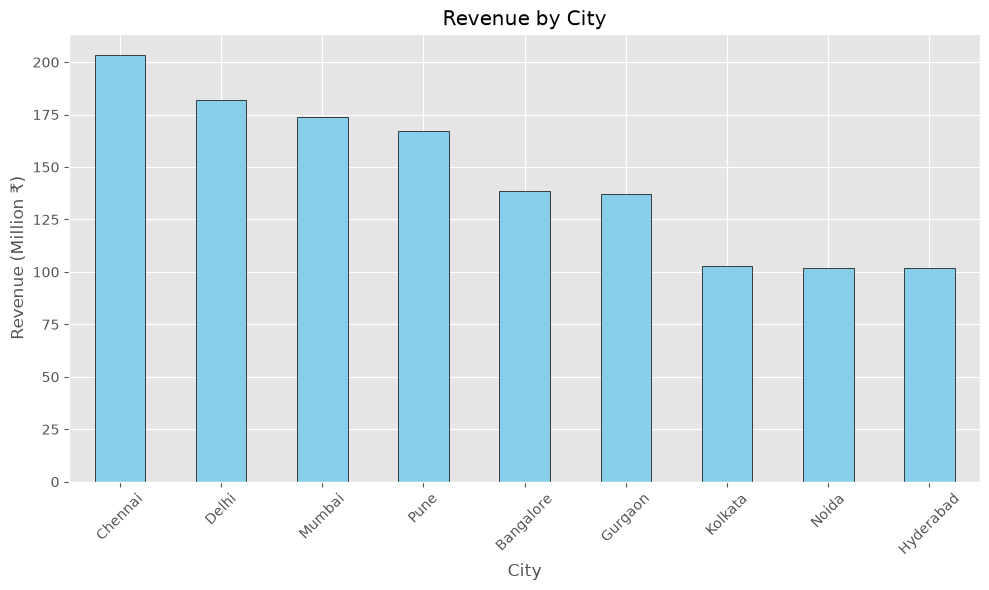

In [59]:
plt.figure(figsize=(10,6))

city_revenue_m.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (Million ₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

- Chennai generated the highest revenue (~203.46 Million ₹).
- Delhi and Mumbai were the next strongest markets.
- Hyderabad and Noida generated comparatively lower revenue.
- Revenue distribution suggests stronger customer demand in metro cities.

# Master Dataset Creation

### Objective
Combine all transactional and lookup tables into a single analytical dataset to simplify further analysis.

This dataset will be used for all subsequent EDA, visualizations and business insights.

In [68]:
master_df = sales.copy()
master_df = master_df.merge(
    products,
    on="ProductID",
    how="left"
)
master_df = master_df.merge(
    stores,
    on="StoreID",
    how="left"
)
master_df = master_df.merge(
    payments,
    on="PaymentID",
    how="left"
)
master_df = master_df.merge(
    promotions,
    on="PromotionID",
    how="left"
)
master_df = master_df.merge(

    customers,

    on="CustomerID",

    how="left"

)
master_df.head()
master_df.shape
master_df.columns

Index(['OrderID', 'OrderDateTime', 'CustomerID', 'ProductID', 'StoreID',
       'PaymentID', 'PromotionID', 'Quantity', 'UnitPrice', 'GrossAmount',
       'DiscountAmount', 'NetAmount', 'DeliveryMinutes', 'OrderStatus',
       'ProductName', 'Category', 'Brand', 'MRP', 'StoreName', 'City_x',
       'OpeningYear', 'PaymentMethod', 'PromotionType', 'DiscountPercent',
       'CustomerName', 'City_y', 'SignupDate', 'CustomerSegment'],
      dtype='str')

In [63]:
master_df.to_csv(
    "../data/Master_Dataset.csv",
    index=False
)

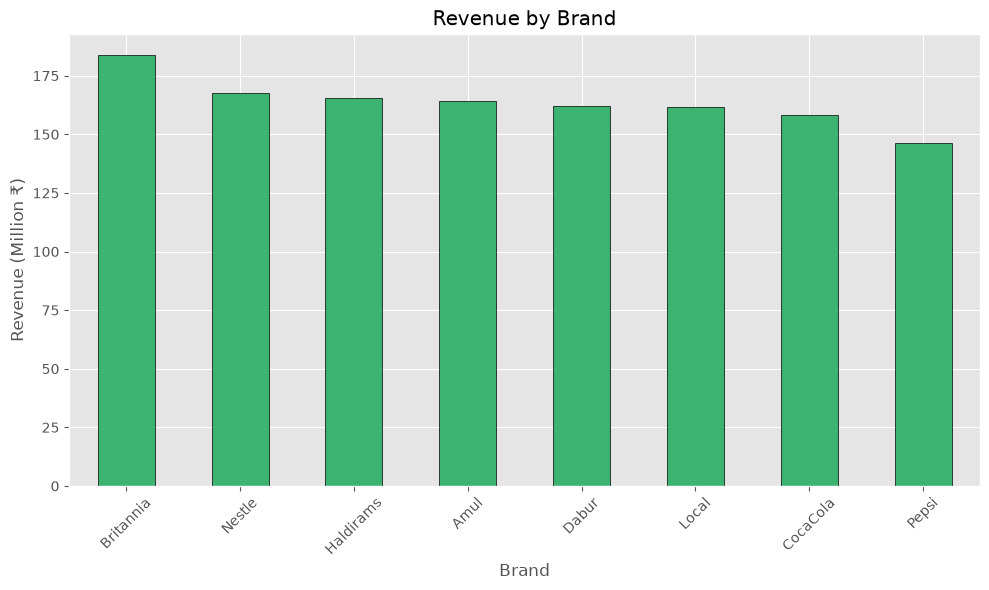

In [64]:
brand_revenue = (
    master_df.groupby("Brand")["NetAmount"]
    .sum()
    .sort_values(ascending=False)
)

brand_revenue_m = (brand_revenue / 1_000_000).round(2)

brand_revenue_m
plt.figure(figsize=(10,6))

brand_revenue_m.plot(
    kind="bar",
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Revenue by Brand")
plt.xlabel("Brand")
plt.ylabel("Revenue (Million ₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- Britannia generated the highest revenue (~171 Million ₹), followed by Nestlé and Haldiram's.
- Revenue is fairly distributed among the leading brands, indicating a diversified product portfolio.
- Top-performing brands should receive greater visibility through personalized recommendations, bundled offers, and promotional campaigns to maximize customer lifetime value.

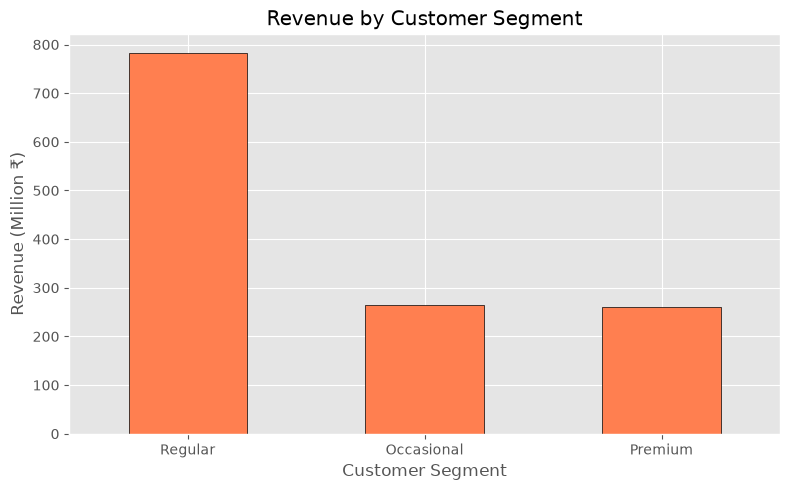

In [69]:
segment_revenue = (
    master_df.groupby("CustomerSegment")["NetAmount"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue_m = (segment_revenue / 1_000_000).round(2)

segment_revenue_m
plt.figure(figsize=(8,5))

segment_revenue_m.plot(
    kind="bar",
    color="coral",
    edgecolor="black"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (Million ₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 💡 Business Insight

- Regular customers contributed the highest revenue by a significant margin.
- Premium customers generated lower overall revenue due to their smaller customer base, despite potentially higher spending per user.
- Increasing the conversion of Regular customers into Premium customers presents a strong opportunity to improve customer lifetime value and retention.

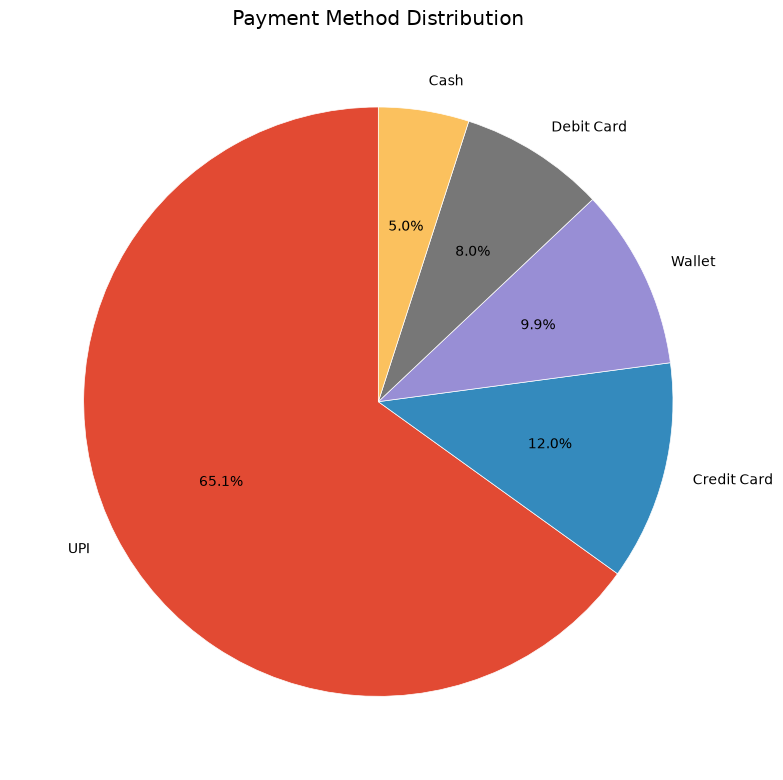

In [72]:
payment_distribution = (
    master_df["PaymentMethod"]
    .value_counts()
)

payment_distribution
plt.figure(figsize=(8,8))

plt.pie(
    payment_distribution,
    labels=payment_distribution.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)

plt.title("Payment Method Distribution")

plt.tight_layout()
plt.show()

## 💳 Payment Method Distribution

### Objective
Analyze customer payment preferences across completed orders.

### Why it matters
Understanding payment preferences helps optimize the checkout experience and prioritize payment partnerships.

### 💡 Business Insight

- UPI is the dominant payment method, accounting for nearly two-thirds of all transactions.
- Credit and Debit Cards are the next most preferred payment options.
- Cash on Delivery contributes a relatively small share in this dataset.
- Optimizing the UPI checkout experience can have the greatest impact on payment success and customer convenience.

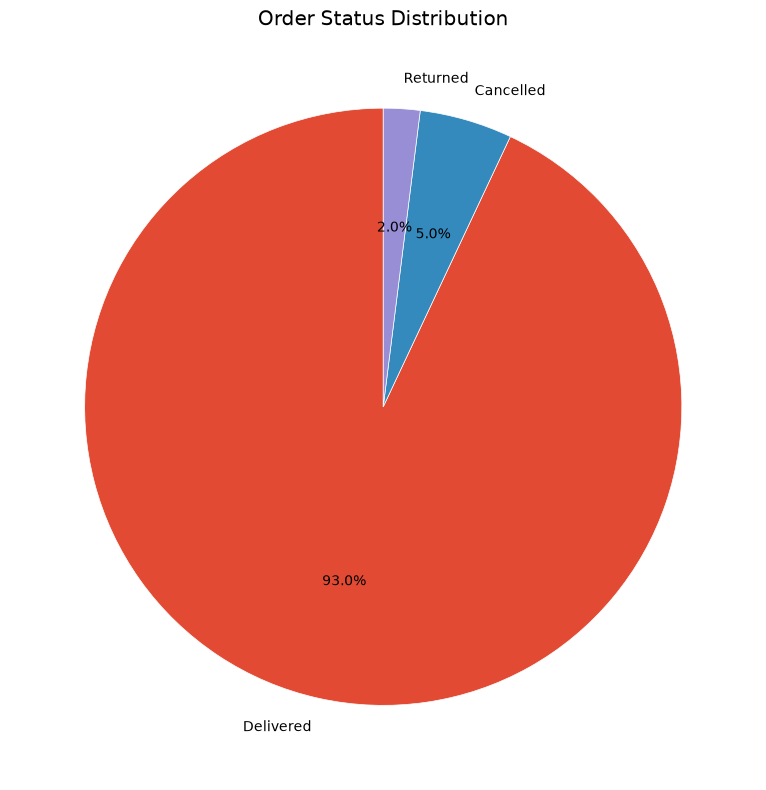

In [74]:
order_status = master_df["OrderStatus"].value_counts()

order_status
plt.figure(figsize=(8,8))

plt.pie(
    order_status,
    labels=order_status.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Order Status Distribution")

plt.tight_layout()
plt.show()

## 📦 Order Status Distribution

### Objective
Analyze the distribution of order outcomes to assess operational reliability.

### Why it matters
Order completion, cancellations, and returns directly impact customer satisfaction, revenue, and retention.

### 💡 Business Insight

- Approximately 93% of orders were successfully delivered.
- Around 5% of orders were cancelled, while 2% were returned.
- Although the fulfillment rate is high, cancellations and returns still represent significant revenue leakage.
- Improving inventory accuracy, delivery reliability, and post-order support can further enhance customer trust and retention.

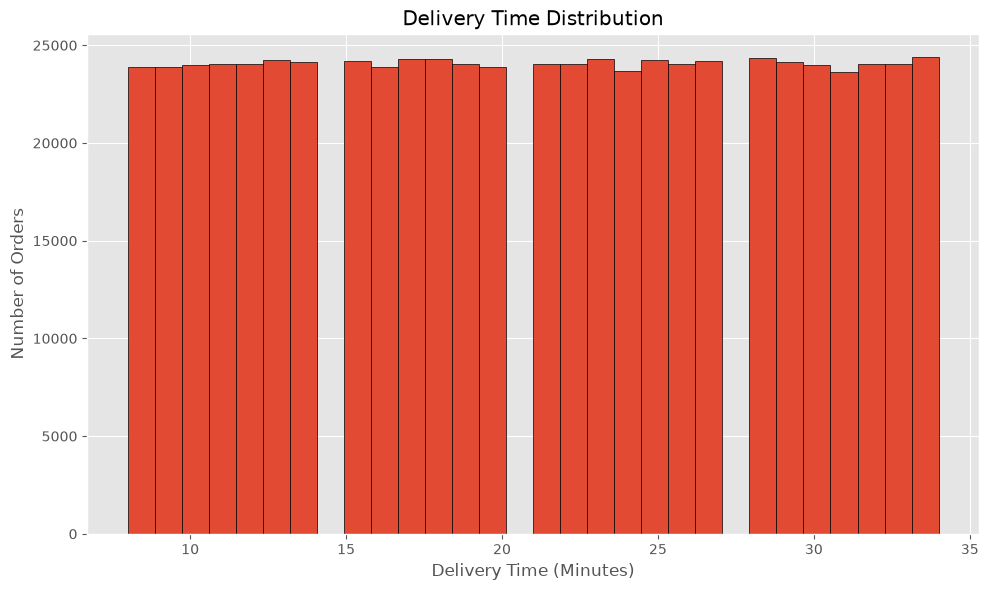

In [82]:
master_df.groupby("City_x")["DeliveryMinutes"].mean()
plt.figure(figsize=(10,6))

plt.hist(
    master_df["DeliveryMinutes"],
    bins=30,
    edgecolor="black"
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## 🚚 Delivery Time Distribution

### Objective
Analyze the distribution of delivery times to evaluate operational efficiency.

### Why it matters
Delivery time is one of Zepto's core value propositions and directly influences customer satisfaction, retention, and repeat purchases.

### 💡 Business Insight

- Most deliveries are completed within 15–30 minutes.
- A small proportion of deliveries experience significantly longer delivery times.
- Reducing delivery time variance through AI-based ETA prediction and routing optimization can improve customer trust and reduce cancellations.

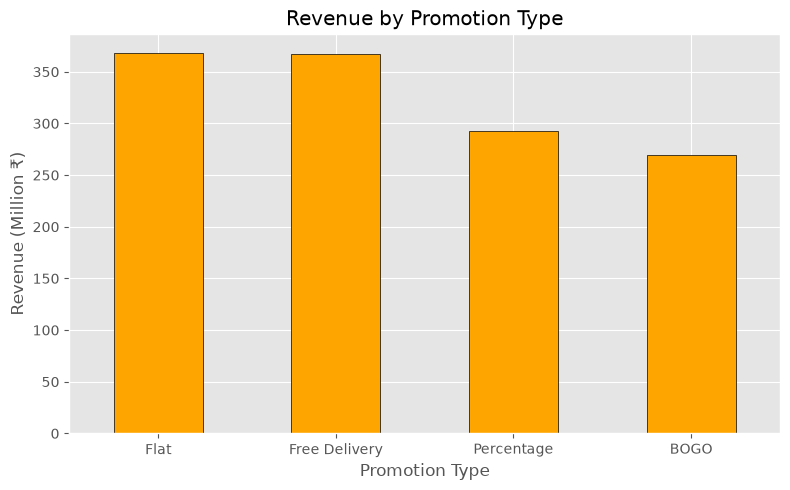

In [83]:
promotion_performance = (
    master_df.groupby("PromotionType")
    .agg(
        Revenue=("NetAmount","sum"),
        Avg_Order_Value=("NetAmount","mean"),
        Orders=("OrderID","count")
    )
    .sort_values("Revenue", ascending=False)
)

promotion_performance["Revenue"] = (
    promotion_performance["Revenue"] / 1_000_000
).round(2)

promotion_performance.round(2)
plt.figure(figsize=(8,5))

promotion_performance["Revenue"].plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Revenue by Promotion Type")
plt.xlabel("Promotion Type")
plt.ylabel("Revenue (Million ₹)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 🏷 Promotion Performance

### Objective
Evaluate how different promotion types influence revenue and average order value.

### Why it matters
Understanding promotion effectiveness helps optimize discount strategies while maximizing revenue and profitability.

### 💡 Business Insight

- Revenue contribution is fairly balanced across all promotion types.
- Flat and Free Delivery promotions generated slightly higher overall revenue.
- Since average order values remain similar across promotion types, blanket discounts may not significantly increase basket size.
- Personalized, AI-driven promotions based on customer purchase behavior could improve conversion while reducing unnecessary discount spending.